# Machine Learning Final Project

*chosen dataset link: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success*

We made sure it meets all of the requirements:

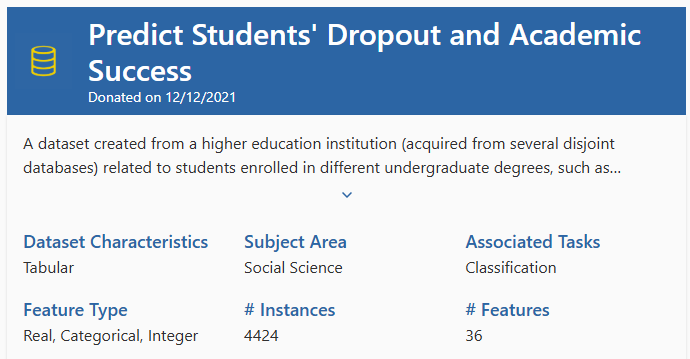

**Hayat Bilici - 1306220011**

**Başak Ay - 1306210065**

**Note:** *We explained how we handled the dataset and completed the requirements of the project in the end of this page, right after the confusing matrix.*

imports & setup for the dataset

In [1]:
# !pip install seaborn
# !pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("default")

**Load Dataset**

In [2]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features

y = dataset.data.targets["Target"]  

df = pd.concat([X, y.rename("Target")], axis=1)



In [3]:
# fixing data--> nacionality
if "Nacionality" in X.columns:
    X = X.rename(columns={"Nacionality": "Nationality"})


Checking if there's any missing values: (there isn't)

In [4]:
df.isnull().values.any()


np.False_

Checking for class imbalance:

In [5]:
y.value_counts(normalize=True)

Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64

Train / Test Split with stratified splitting to preserve class distribution:

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


We use macro-averaged metrics to balance the importance of all classes.
(Accuracy ((TP+TN)/all) hides imbalance, so we use F1-score):

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

categorical_cols = [
    "Marital Status","Application mode","Application order","Course",
    "Daytime/evening attendance","Previous qualification","Nationality",
    "Mother's qualification","Father's qualification",
    "Mother's occupation","Father's occupation"
]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Dropout       0.81      0.68      0.74       284
    Enrolled       0.41      0.64      0.50       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.70      0.69       885
weighted avg       0.76      0.72      0.74       885



**Dataset Overview**

In [8]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [9]:
target_col = df.columns[-1]   
df[target_col].value_counts()


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

**Class distribution**

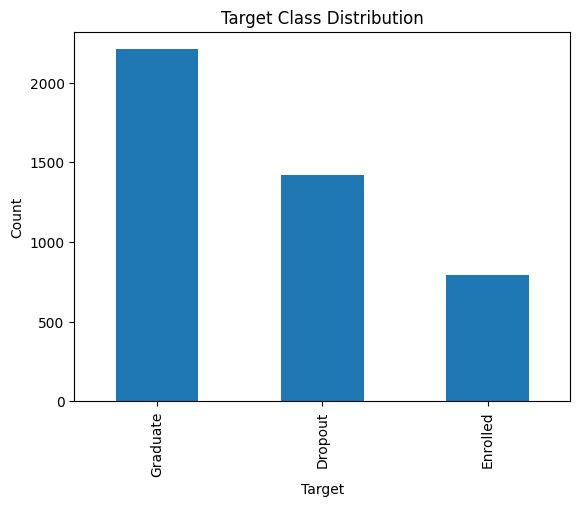

In [10]:
df[target_col].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.ylabel("Count")
plt.show()


**Feature Type Identification**

In [11]:
categorical_cols = [
    "Marital Status","Application mode","Application order","Course",
    "Daytime/evening attendance","Previous qualification","Nationality",
    "Mother's qualification","Father's qualification",
    "Mother's occupation","Father's occupation",
    "Displaced","Educational special needs","Debtor",
    "Tuition fees up to date","Gender","Scholarship holder","International"
]

numeric_cols = [c for c in X.columns if c not in categorical_cols]


**Preprocessing Pipeline**

In [12]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)


Baseline Model *(DummyClassifier)*

In [13]:
dummy_model = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)
dummy_preds = dummy_model.predict(X_test)

print("Dummy Classifier Results:")
print(classification_report(y_test, dummy_preds, zero_division=0))



Dummy Classifier Results:
              precision    recall  f1-score   support

     Dropout       0.00      0.00      0.00       284
    Enrolled       0.00      0.00      0.00       159
    Graduate       0.50      1.00      0.67       442

    accuracy                           0.50       885
   macro avg       0.17      0.33      0.22       885
weighted avg       0.25      0.50      0.33       885



***Logistic Regression Model***

In [14]:
logreg_model = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, logreg_preds))


Logistic Regression Results:
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.75       284
    Enrolled       0.41      0.64      0.50       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



***Random Forest Model***

In [15]:
rf_model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_preds))


Random Forest Results:
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.52      0.27      0.36       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.73      0.76      0.74       885



**Hyperparameter Tuning** *(Random Forest)*

In [16]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(rf_model, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_


**Hyperparameter Tuning** *(Logistic Regression)*

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"]
}

grid = GridSearchCV(
    logreg_model,
    param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_logreg = grid.best_estimator_
print("Best parameters:", grid.best_params_)


Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}


# Final Evaluation

In [18]:
best_preds = best_logreg.predict(X_test)

print("Tuned Logistic Regression Results:")
print(classification_report(y_test, best_preds, zero_division=0))


Tuned Logistic Regression Results:
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.42      0.65      0.51       159
    Graduate       0.87      0.80      0.83       442

    accuracy                           0.73       885
   macro avg       0.71      0.71      0.70       885
weighted avg       0.78      0.73      0.75       885



**ROC curve** (macro-averaged, multiclass)

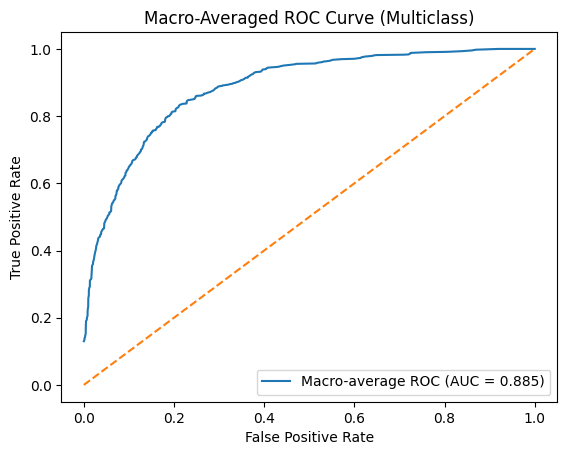

Per-class AUC:
Dropout: 0.914
Enrolled: 0.814
Graduate: 0.925


In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model_for_roc = grid.best_estimator_   

model_for_roc.fit(X_train, y_train)

proba = model_for_roc.predict_proba(X_test)

classes = model_for_roc.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Averaged ROC Curve (Multiclass)")
plt.legend(loc="lower right")
plt.show()

print("Per-class AUC:")
for i, c in enumerate(classes):
    print(f"{c}: {roc_auc[i]:.3f}")


**Metric comparison bar chart** *(Dummy vs LogReg vs RF)*

,Accuracy,Macro F1
Model,,
Dummy (most_frequent),0.499435,0.222055
Logistic Regression,0.725424,0.689507
Random Forest,0.757062,0.658317


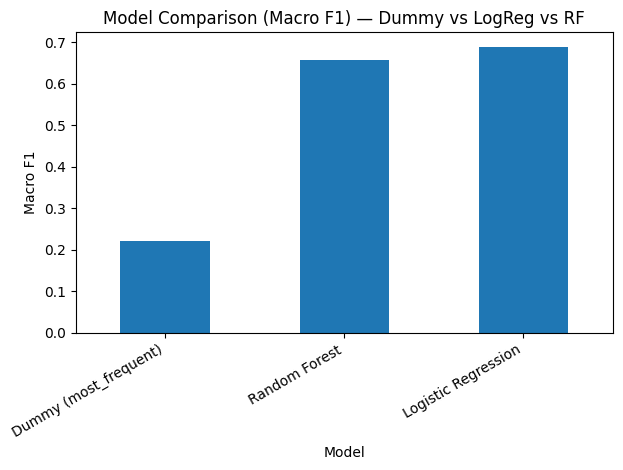

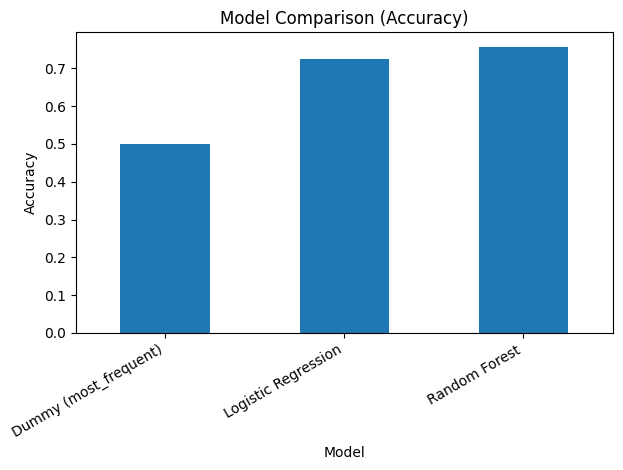

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score

models = {
    "Dummy (most_frequent)": dummy_model,
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Macro F1": f1_score(y_test, preds, average="macro")
    })

results_df = pd.DataFrame(rows).set_index("Model")
display(results_df)

# Bar chart (Macro F1)
plt.figure()
results_df["Macro F1"].sort_values().plot(kind="bar")
plt.ylabel("Macro F1")
plt.title("Model Comparison (Macro F1) — Dummy vs LogReg vs RF")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
results_df["Accuracy"].sort_values().plot(kind="bar")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Confusion Matrix

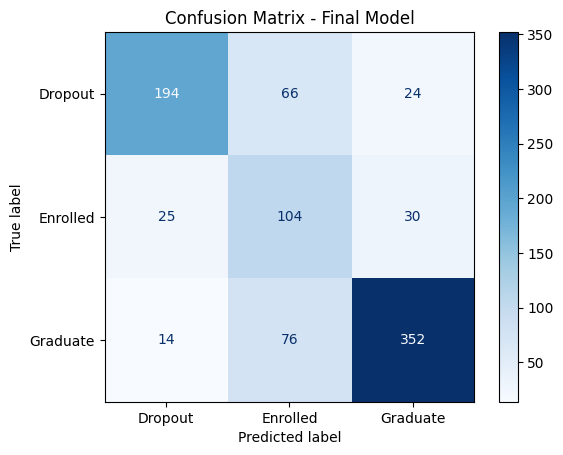

In [21]:
final_preds = model_for_roc.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_preds,
    labels=model_for_roc.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix - Final Model")
plt.show()


# 6.1. Data understanding & preprocessing

**Missing Values**: Handled with *SimpleImputer* //no missing values

**Wrong values**: changed

**Outliers**: implicitly handled 

**Class imbalance**: checked and justified using F1-Score macro

**Categorical & Numeric**: separated *OneHotEncoder(handle_unknown="ignore")*

**Scaling**: *StandardScaler* used

# 6.2 Baseline and modelling

**Baseline**: DummyClassifier(strategy="most_frequent") used to predict the majority class and serve as a minimal performance benchmark.

**Real Models**: We used 2 of them: *Logistic Regression* and *Random Forest*

**Hyperparameter search**: done with *GridSearchCV*


# 6.3 Evaluation design

**Validation Strategy**: We used *train_test_split(X, y, test_size=0.2, stratify=y)*
--> We chose ***stratification*** because it ensures that each class keeps the same proportion in both training and test sets. Without stratification, minority classes may almost disappear from the test set, evaluation becomes unreliable, and metrics like F1 and ROC become unstable. To summarize, we used a stratified train–test split to preserve the original class distribution across splits, ensuring fair and reliable evaluation, especially given class imbalance.

**Accuracy Insufficiency**: In imbalanced datasets, a model can achieve high accuracy by ignoring minority classes, therefore accuracy doesn't reflect per-class performajnce. We used *Macro F1-Score* because it computes F1 independently for each class and prevents majority class dominance. We also used *ROC-AUC* which measures the trade off between TP and FP rates. (macro + multiclass for explained reasonings.)

**Confusion Matrix**: included as well as *Macro ROC*. Enables error analysis, demonstrating the confusion between classes.

# 6.4. Analysis and interpretation

**The best model**: was chosen not based on accuracy but on macro F1 & ROC-AUC for their reflection balanced performance across all classes. The selected model also showed more stable behavior in the confusion matrix, especially on minority classes.

**Error Analysis**: We observed that misclassifications mainly occur between semantically similar outcome classes; pointing at an overlapping feature patter rather than random errors.

**Meaningful Plots**: *Metric comparison bar chart* (Dummy vs Logistic Regression vs Random Forest) and *Macro-averaged ROC curve* included.

This section is further explained in our report.

prepared by --> *Hayat Bilici* & *Başak Ay*